# Imports

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import torch
import numpy as np
from tqdm.notebook import tqdm

# Asegurar que la ruta src está en el path
PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT / "src"))

# Importaciones locales
from dataset.efficientdet_dataset import EfficientDetDataset
from models.efficientdet import EfficientDet
from utils.data_augmentations import get_transforms
from utils.file_utils import read_yaml
from engine.train_efficientdet import train_efficientdet

# Configuración de rutas
yaml_config_path = PROJECT_ROOT / "dataset" / "processed" / "experiments" / "set1_balanced_subsampled" / "fold_1_config.yaml"
config = read_yaml(yaml_config_path)
class_names = {i: name for i, name in enumerate(config['names'])}
img_size = 640

print(f"🚀 Entorno configurado. Detectando clases: {list(class_names.values())}")

/home/cgonzalez/Object_Recognition/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🚀 Entorno configurado. Detectando clases: ['horse', 'penguin', 'pig']


# Cargamos el dataset

📦 Resumen del Target:
   - Cajas (YXYX): torch.Size([29, 4])
   - Clases: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1])


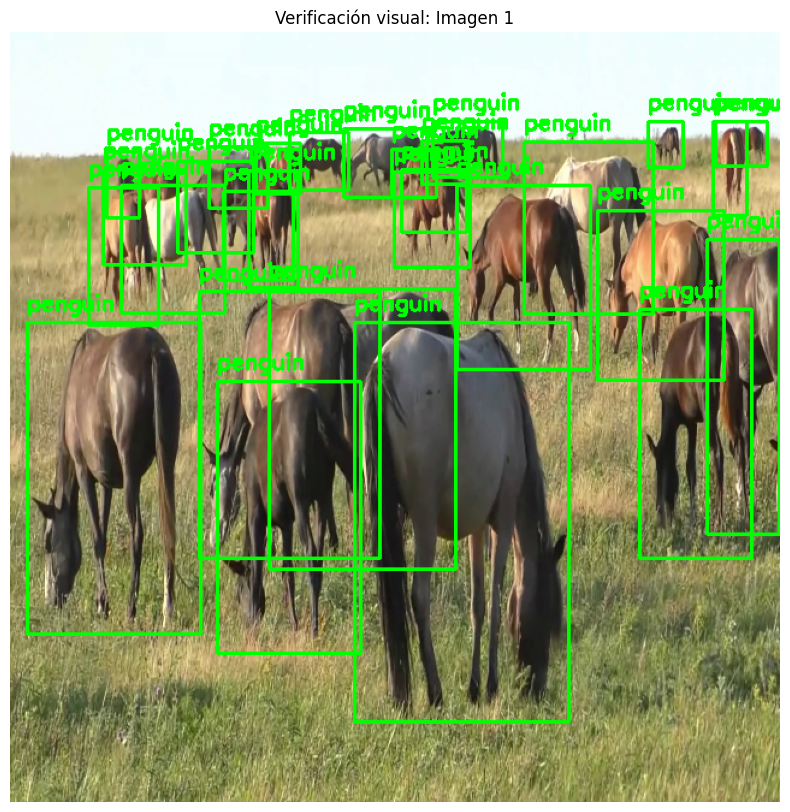

In [2]:
train_ds = EfficientDetDataset(Path(config['train']), img_size=img_size, transforms=get_transforms('val',img_size))

# Extraer un ejemplo (ID 10 suele ser el de los caballos en el agua)
idx = 1
img_tensor, target = train_ds[idx]

print(f"📦 Resumen del Target:")
print(f"   - Cajas (YXYX): {target['bbox'].shape}")
print(f"   - Clases: {target['cls']}")

# --- Visualización ---
mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
img_np = img_tensor.permute(1, 2, 0).numpy()
img_np = (img_np * std) + mean
img_np = (np.clip(img_np, 0, 1) * 255).astype("uint8").copy()

for box, cls_id in zip(target['bbox'], target['cls']):
    y1, x1, y2, x2 = map(int, box) # Dataset devuelve YXYX
    name = class_names.get(int(cls_id), "Unknown")
    cv2.rectangle(img_np, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(img_np, name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

plt.figure(figsize=(10, 10))
plt.imshow(img_np)
plt.title(f"Verificación visual: Imagen {idx}")
plt.axis('off')
plt.show()

# Entrenamiento

Loading pre-trained tf_efficientdet_d1 (COCO)...


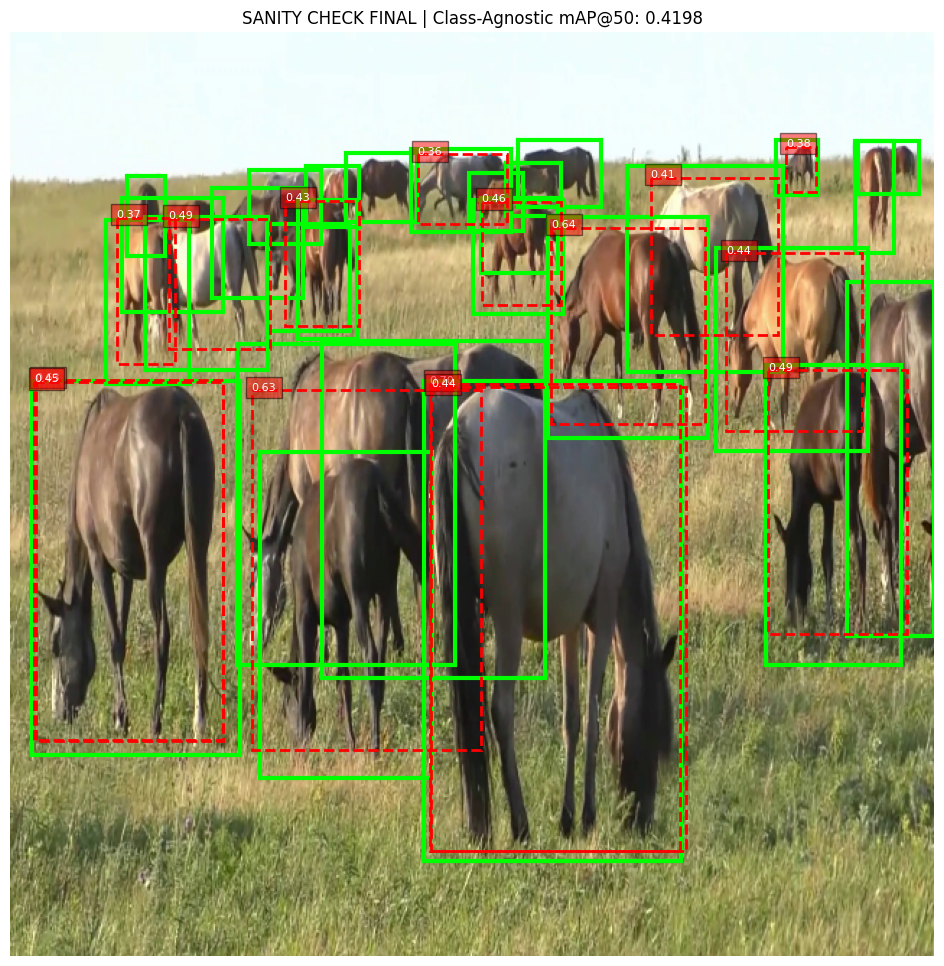

✅ Validación completada. mAP@50 (Localización): 0.4198


In [3]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from effdet import create_model
from torchmetrics.detection.mean_ap import MeanAveragePrecision

# ==========================================
# 1. CONFIGURACIÓN Y CARGA DE MODELO COCO
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
img_size = 640  # Asegúrate de que coincida con tu entrenamiento
model_name = 'tf_efficientdet_d1'

print(f"Loading pre-trained {model_name} (COCO)...")
model_coco = create_model(
    model_name,
    bench_task='predict',
    num_classes=90, # COCO original
    pretrained=True,
    image_size=(img_size, img_size)
).to(device)
model_coco.eval()

# ==========================================
# 2. CARGA DE DATOS (Tu Dataset)
# ==========================================
# Asumimos que train_ds ya está definido en tu notebook, si no:
# train_ds = EfficientDetDataset(Path(config['train']), img_size=img_size, transforms=get_transforms('val', img_size))

idx = 1  # El índice de la imagen de los caballos
img_tensor, target = train_ds[idx]

# ==========================================
# 3. INFERENCIA
# ==========================================
input_tensor = img_tensor.unsqueeze(0).to(device)
with torch.no_grad():
    detections = model_coco(input_tensor) # [1, 100, 6] -> [x1, y1, x2, y2, score, cls]

# ==========================================
# 4. CÁLCULO DE mAP AGNÓSTICO (Solo localización)
# ==========================================
metric = MeanAveragePrecision(box_format='xyxy')

# A. PREPARAR PREDICCIONES
# Filtramos por confianza > 0.3 y forzamos label a 1
d = detections[0].cpu()
mask = d[:, 4] > 0.3
p_boxes = d[mask, :4]
p_scores = d[mask, 4]
p_labels = torch.ones_like(p_scores).to(torch.int64) # Hack: Todo es clase 1

preds_metrics = [{"boxes": p_boxes, "scores": p_scores, "labels": p_labels}]

# B. PREPARAR GROUND TRUTH
# Convertimos YXYX a XYXY y forzamos label a 1
gt_boxes_yxyx = target['bbox']
gt_boxes_xyxy = gt_boxes_yxyx[:, [1, 0, 3, 2]]
gt_labels = torch.ones(len(gt_boxes_xyxy)).to(torch.int64) # Hack: Todo es clase 1

target_metrics = [{"boxes": gt_boxes_xyxy, "labels": gt_labels}]

# C. CALCULAR
metric.update(preds_metrics, target_metrics)
result = metric.compute()
map_50 = result['map_50'].item()

# ==========================================
# 5. VISUALIZACIÓN FINAL
# ==========================================
# Desnormalizar imagen
mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
img_vis = img_tensor.permute(1, 2, 0).cpu().numpy()
img_vis = (np.clip((img_vis * std) + mean, 0, 1) * 255).astype(np.uint8).copy()

plt.figure(figsize=(12, 12))
plt.imshow(img_vis)
ax = plt.gca()

# Dibujar GT (Verde)
for box in gt_boxes_xyxy:
    x1, y1, x2, y2 = box.numpy()
    ax.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='#00FF00', linewidth=3))

# Dibujar Predicciones (Rojo)
for box, score in zip(p_boxes, p_scores):
    x1, y1, x2, y2 = box.numpy()
    ax.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red', linewidth=2, linestyle='--'))
    ax.text(x1, y1, f'{score:.2f}', color='white', fontsize=8, bbox=dict(facecolor='red', alpha=0.5))

plt.title(f"SANITY CHECK FINAL | Class-Agnostic mAP@50: {map_50:.4f}")
plt.axis('off')
plt.show()

print(f"✅ Validación completada. mAP@50 (Localización): {map_50:.4f}")

In [4]:
# %% [markdown]
# # Importaciones y Configuración del Entorno

import sys
from pathlib import Path
import torch

# 1. Añadimos la carpeta 'src' al path de Python para poder importar nuestros módulos
PROJECT_ROOT = Path().resolve().parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

# 2. Importamos nuestra función de entrenamiento recién creada
from engine.train_efficientdet import train_efficientdet

# 3. Comprobamos la GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo configurado: {device}")

Dispositivo configurado: cuda


In [5]:
# %% [markdown]
# # Definición del Experimento

# Ruta al archivo YAML generado en el notebook 03 (Split)
EXPERIMENT_NAME = "set1_balanced_subsampled"
FOLD = 1

YAML_PATH = PROJECT_ROOT / f"dataset/processed/experiments/{EXPERIMENT_NAME}/fold_{FOLD}_config.yaml"

# Carpeta donde se guardarán los pesos (.pt), los gráficos y las predicciones de test
OUTPUT_DIR = PROJECT_ROOT / f"runs/efficientdet/{EXPERIMENT_NAME}/fold_{FOLD}"

print(f"Archivo de configuración: {YAML_PATH}")
print(f"Carpeta de salida: {OUTPUT_DIR}")

Archivo de configuración: /home/cgonzalez/Object_Recognition/dataset/processed/experiments/set1_balanced_subsampled/fold_1_config.yaml
Carpeta de salida: /home/cgonzalez/Object_Recognition/runs/efficientdet/set1_balanced_subsampled/fold_1


In [6]:
# if torch.cuda.is_available():
#     torch.cuda.empty_cache()

# if torch.cuda.is_available():
#     torch.cuda.empty_cache()

# train_efficientdet(
#     yaml_path=str(YAML_PATH),
#     output_dir=str(OUTPUT_DIR),
    
#     # --- FASE 1: TRANSFER LEARNING ---
#     epochs_tl=10,          # Con 10 épocas agresivas es suficiente (como en el original)
#     lr_tl=1e-3,            
#     warmup_epochs=0,       # 🔴 ¡CLAVE! Cero warmup. Queremos que arranque a 1e-3 desde el paso 1.
    
#     # --- FASE 2: FINE-TUNING ---
#     epochs_ft=5,          
#     lr_ft=1e-4,            
    
#     # --- PARÁMETROS GENERALES ---
#     batch_size=4,          # 🔴 Volvemos a 4 para tener 23 actualizaciones por época.
#     img_size=640,          
#     weight_decay=1e-4,     
#     architecture='tf_efficientdet_d1',
    
#     # --- OPTIMIZADOR Y SCHEDULER ---
#     optimizer_str='adamw', 
#     scheduler_str='cosine',
#     early_stop_patience=15,
    
#     device=device
# )

In [11]:
# %% [markdown]
# # LANZAMIENTO DEL ENTRENAMIENTO AUTOMATIZADO

# %%
import torch
from pathlib import Path

# Importamos la nueva función del pipeline que acabamos de crear
from engine.train_pipeline import train_efficientdet_pipeline


# ==========================================
# CONFIGURACIÓN
# ==========================================
EXPERIMENT_NAME = "set1_balanced_subsampled"
FOLD = 1

YAML_PATH = PROJECT_ROOT / f"dataset/processed/experiments/{EXPERIMENT_NAME}/fold_{FOLD}_config.yaml"

# Carpeta donde se guardarán los pesos (.pt), los gráficos y las predicciones de test
OUTPUT_DIR = PROJECT_ROOT / f"runs/efficientdet/{EXPERIMENT_NAME}/fold_{FOLD}"


# Comprobación rápida de hardware
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Hardware disponible: {device}")

# ==========================================
# EJECUCIÓN
# ==========================================
train_efficientdet_pipeline(
    yaml_path=str(YAML_PATH),
    output_dir=str(OUTPUT_DIR),
    epochs_tl=5,            # Fase 1: Solo cabezas
    epochs_ft=30,           # Fase 2: Toda la red
    batch_size=16,           # Ajusta según tu VRAM
    img_size=720,           # Tamaño que demostró funcionar en tu prueba
    lr_tl=1e-3,             # Learning rate para Warmup/TL
    lr_ft=1e-4,             # Learning rate seguro para Fine-Tuning
    architecture='tf_efficientdet_d3',
    optimizer_str='adamw',
    scheduler_str='cosine',
    early_stop_patience=10, # Cortar antes si no mejora en Fase 2
    weight_decay=2e-4,      # Regularización estándar para EfficientDet
    dropout_rate = 0,
    device=device
)

Hardware disponible: cuda

🚀 STARTING TRAINING: 5 epochs TL + 30 epochs FT en cuda


Phase 1: Transfer Learning (TL) - 5 epochs
✅ Backbone frozen, head unfrozen


📊 Epoch 1 [TL]: TrainLoss=1.4027 | ValLoss=1.3074 | mAP@50=0.1395


📊 Epoch 2 [TL]: TrainLoss=1.1808 | ValLoss=1.2560 | mAP@50=0.2261


📊 Epoch 3 [TL]: TrainLoss=1.0417 | ValLoss=1.2487 | mAP@50=0.2354


📊 Epoch 4 [TL]: TrainLoss=0.9414 | ValLoss=1.2254 | mAP@50=0.2196


...

📊 Epoch 20 [FT]: TrainLoss=0.3679 | ValLoss=0.8555 | mAP@50=0.4683


📊 Epoch 21 [FT]: TrainLoss=0.3780 | ValLoss=0.8360 | mAP@50=0.4859
🏆 New Best mAP@50 (Fine-Tuning)!


📊 Epoch 22 [FT]: TrainLoss=0.3702 | ValLoss=0.8279 | mAP@50=0.4938
🏆 New Best mAP@50 (Fine-Tuning)!


📊 Epoch 23 [FT]: TrainLoss=0.3549 | ValLoss=0.8161 | mAP@50=0.4948
🏆 New Best mAP@50 (Fine-Tuning)!


KeyboardInterrupt: 

In [8]:
from effdet import get_efficientdet_config, create_model_from_config, DetBenchTrain, DetBenchPredict

In [9]:
config = get_efficientdet_config("tf_efficientdet_d1")
config.fpn_drop_path_rate = 0.2

In [10]:
model = create_model